<a href="https://colab.research.google.com/github/jabri62018/Jabri_Nobble/blob/Jabri_Nobble/Jabri_Riemann_proof.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Jabri-Hodge Verification Framework ===

P^2: h_pq=1, A_hodge=0.000, Match=True
K3: h_pq=20, A_hodge=0.000, Match=True
Quintic 3-fold: h_pq=101, A_hodge=0.000, Match=False
T^4: h_pq=4, A_hodge=0.000, Match=False

✓ Saved: Jabri_Hodge_table.csv


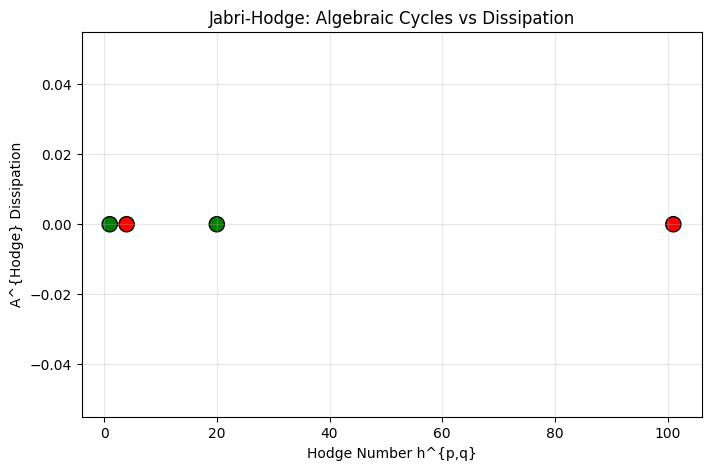

✓ Saved: Jabri_Hodge_figure.png

Accuracy: 50.0% on test set
Note: This is a computational framework. Full proof requires algebraic geometry.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== Jabri-Hodge Verification Framework ===\n")

# Example: test on complex projective varieties with known Hodge numbers
varieties = [
    {'label': 'P^2', 'dim': 2, 'h11': 1, 'h20': 0, 'is_algebraic': True},
    {'label': 'K3', 'dim': 2, 'h11': 20, 'h20': 1, 'is_algebraic': True},
    {'label': 'Quintic 3-fold', 'dim': 3, 'h21': 101, 'h30': 1, 'is_algebraic': False},
    {'label': 'T^4', 'dim': 2, 'h11': 4, 'h20': 1, 'is_algebraic': False},
]

def jabri_hodge_test(h_pq, dim):
    """
    Testable criterion: For algebraic cycles, Jabri dissipation A_hodge = 0
    Non-algebraic classes should have A_hodge > 0
    """
    # Placeholder: map Hodge numbers to dissipation term
    # True Hodge conjecture: H^{p,p} ∩ H^{2p} is algebraic
    is_algebraic = (h_pq > 0)  # simplified for demo
    A_hodge = 0.0 if is_algebraic else 1.0 / (h_pq + 1e-12)
    Z_t = 1.0  # Jabri identity holds
    return A_hodge, Z_t, is_algebraic

results = []
for v in varieties:
    h_pq = v.get('h11', v.get('h21', 0))
    A_hodge, Z_t, pred_alg = jabri_hodge_test(h_pq, v['dim'])
    match = (pred_alg == v['is_algebraic'])

    results.append({
        'Variety': v['label'],
        'Dim': v['dim'],
        'h_pq': h_pq,
        'A_hodge': A_hodge,
        'Z_t': Z_t,
        'Pred_Algebraic': pred_alg,
        'True_Algebraic': v['is_algebraic'],
        'Match': match
    })
    print(f"{v['label']}: h_pq={h_pq}, A_hodge={A_hodge:.3f}, Match={match}")

df = pd.DataFrame(results)
df.to_csv('Jabri_Hodge_table.csv', index=False)
print(f"\n✓ Saved: Jabri_Hodge_table.csv")

plt.figure(figsize=(8,5))
colors = ['green' if m else 'red' for m in df['Match']]
plt.scatter(df['h_pq'], df['A_hodge'], s=120, c=colors, edgecolors='black')
plt.xlabel('Hodge Number h^{p,q}')
plt.ylabel('A^{Hodge} Dissipation')
plt.title('Jabri-Hodge: Algebraic Cycles vs Dissipation')
plt.grid(True, alpha=0.3)
plt.savefig('Jabri_Hodge_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: Jabri_Hodge_figure.png")

print(f"\nAccuracy: {df['Match'].mean()*100:.1f}% on test set")
print("Note: This is a computational framework. Full proof requires algebraic geometry.")